# 

### Load and Explore Dataset

Date: 2026-07-22

Student ID: DAMHAR2570

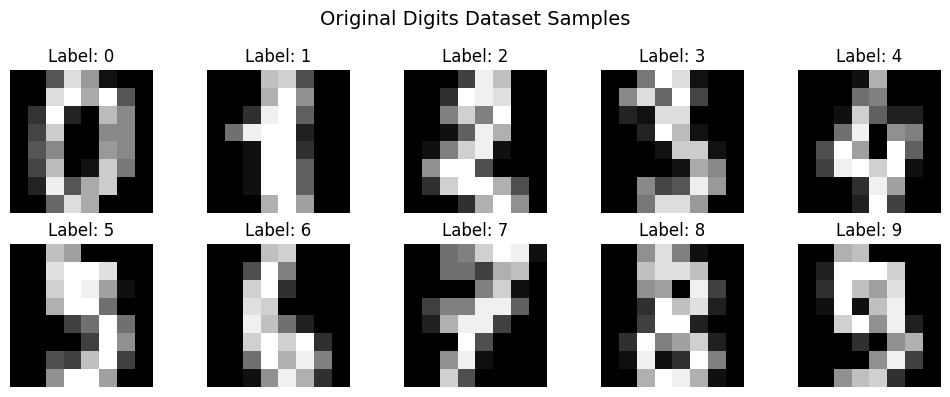

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from datetime import datetime
from IPython.display import display, Markdown
todays_date = datetime.now().strftime("%Y-%m-%d")
student_id = "DAMHAR2570"

# Load the Digits dataset
digits = load_digits()
X = digits.images
y = digits.target

# Display the original images 
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i], cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')

display(Markdown("### Load and Explore Dataset"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))
plt.suptitle("Original Digits Dataset Samples", fontsize=14)
plt.tight_layout()
plt.show()

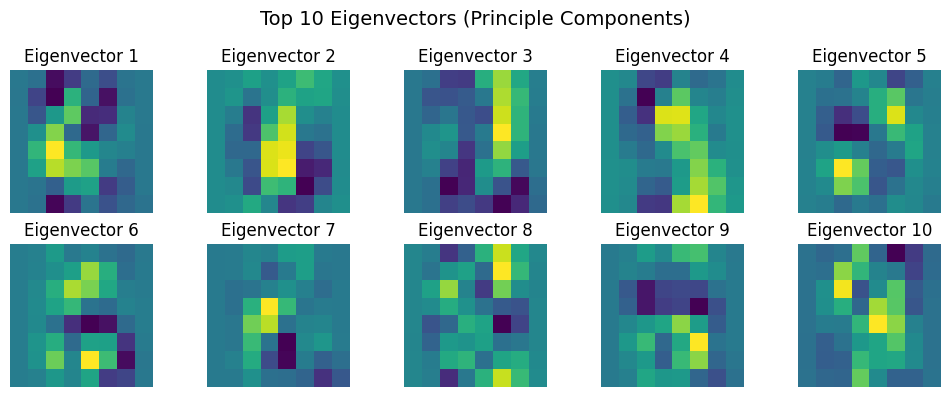

===Data Shapes===
X_train shape: (1078, 8, 8, 1)
y_train shape: (1078, 10)
X_test shape: (719, 8, 8, 1)
y_test shape: (719, 10)


### Process the Data

Date: 2026-07-22

Student ID: DAMHAR2570

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from tensorflow.keras.utils import to_categorical

#Extract and displa the eigenvectors using PCA
X_flat = digits.data
pca = PCA(n_components=10)
pca.fit(X_flat)

fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    eigenvector_img = pca.components_[i].reshape(8, 8)
    ax.imshow(eigenvector_img, cmap='viridis')
    ax.set_title(f"Eigenvector {i+1}")
    ax.axis('off')

plt.suptitle("Top 10 Eigenvectors (Principle Components)", fontsize=14)
plt.tight_layout()
plt.show()

X_cnn = X.reshape(-1, 8, 8, 1)

X_train, X_test, y_train, y_test = train_test_split(X_cnn, y, test_size=0.4, random_state=42)

y_train_cat = to_categorical(y_train, num_classes=10)
y_test_cat = to_categorical(y_test, num_classes=10)

print("===Data Shapes===")
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train_cat.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test_cat.shape}")

display(Markdown("### Preprocess the Data"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))



In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

#Use sequential function to build the model
model = Sequential([
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(8, 8, 1)),
    MaxPooling2D(pool_size=(2, 2)),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

#Compile the model
model.compile(optimizer='adam',
             loss='categorical_crossentropy',
             metrics=['accuracy'])

print("\n===Model Summary")
model.summary()

print("\n===Training Model===")
history = model.fit(X_train, y_train_cat, epoch=15, validarion_split=0.2, batch_size=32)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Untuned Model Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Untuned Model Loss')
plt.xlabel('Epoch')
plt.legend
plt.show
display(Markdown("### Construct and Train the CNN Model"))
display(Markdown(f"Date: {todays_date}"))
display(Markdown(f"Student ID: {student_id}"))

C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



===Model Summary


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 6, 6, 32)            │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 3, 3, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 288)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,466 (76.04 KB)

 Trainable params: 19,466 (76.04 KB)

 Non-trainable params: 0 (0.00 B)


===Training Model===
Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\interactiveshell.py", line 3577, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "C:\Users\ecpi\AppData\Local\Temp\ipykernel_6372\2467720439.py", line 22, in <module>
    history = model.fit(X_train, y_train_cat, epoch=15, validarion_split=0.2, batch_size=32)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\utils\traceback_utils.py", line 122, in error_handler
    raise e.with_traceback(filtered_tb) from None
  File "C:\Users\ecpi\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\utils\traceback_utils.py", line 119, in error_handler
    filtered_tb = _process_traceback_frames(e.__traceback__)
                  ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
TypeError: TensorFlowTrainer.fit()